In [5]:
import pandas as pd

# Load the datasets from the specified paths
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")



## Visulaisierung der Aminosäurezusammensetzung von CDR-Sequenzen

In [6]:
import pandas as pd

# Datensets laden (vorher in data cleanup Ordner erstellt)
df_corona = pd.read_csv("../data cleanup/sars_cov2_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../data cleanup/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../data cleanup/influenza_cdr_seq.tsv", sep="\t")



In [51]:
# Mapping von 1-Buchstaben zu 3-Buchstaben Aminosäuren
aa_1_to_3 = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
} 

# Berechnen wie oft eine Aminosäure in der jeweiligen CDRs vorkommt (in Prozent)
def calculate_aa_distribution(df, column):
    aa_counts = df[column].dropna().apply(lambda x: pd.Series(list(x))).stack().value_counts() # wie oft jede AS vorkommt
    total_count = aa_counts.sum() # Totale Anzahl der Aminosäuren in der jeweiligen CDR-Region
    aa_distribution = (aa_counts / total_count * 100).round(2) # konvertiere in Prozent und runde auf 2 Dezimalstellen
    return aa_distribution 


import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_aa_distribution(corona, influenza, human, region_label="CDR_H3"): #definition der Funktion um die Verteilung der Aminosäuren zu plotten
    """
    Plots the grouped amino acid distribution for three datasets.
    Args:
        corona (pd.Series): Amino acid distribution for Corona.
        influenza (pd.Series): Amino acid distribution for Influenza.
        human (pd.Series): Amino acid distribution for Human.
        region_label (str): Label for the region being analyzed.
    """

    aa_order = list(aa_1_to_3.keys()) # aa_order ist eine Liste der Aminosäuren in der Reihenfolge von aa_1_to_3
    labels_3 = [aa_1_to_3[aa] for aa in aa_order] # labels_3 ist eine Liste der Aminosäuren in der 3-Buchstaben Abkürzung

    # Reindexiere die Verteilung der Aminosäuren, um sicherzustellen, dass alle Aminosäuren in der gleichen Reihenfolge sind
    corona = corona.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Corona
    influenza = influenza.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Influenza
    human = human.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Human

    x = np.arange(len(aa_order)) # Positionen der Balken auf der x-Achse
    width = 0.25 # Breite der Balken

    # Generieren  des Balkendiagramms
    plt.figure(figsize=(12, 6)) # Größe des Diagramms
    # Balken, Position, Label und Farbe
    plt.bar(x - width, corona.values, width, label='Corona', color="#B3E3F4") 
    plt.bar(x,         influenza.values, width, label='Influenza', color='#0BBCC5') 
    plt.bar(x + width, human.values, width, label='Human', color='#132740') 

    plt.xticks(ticks=x, labels=labels_3, rotation=45)
    plt.ylabel("Häufigkeit (%)")
    plt.xlabel("Aminosäure")
    plt.title(f"Aminosäureverteilung in {region_label}")
    plt.ylim(0, 25)  
    plt.legend()
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


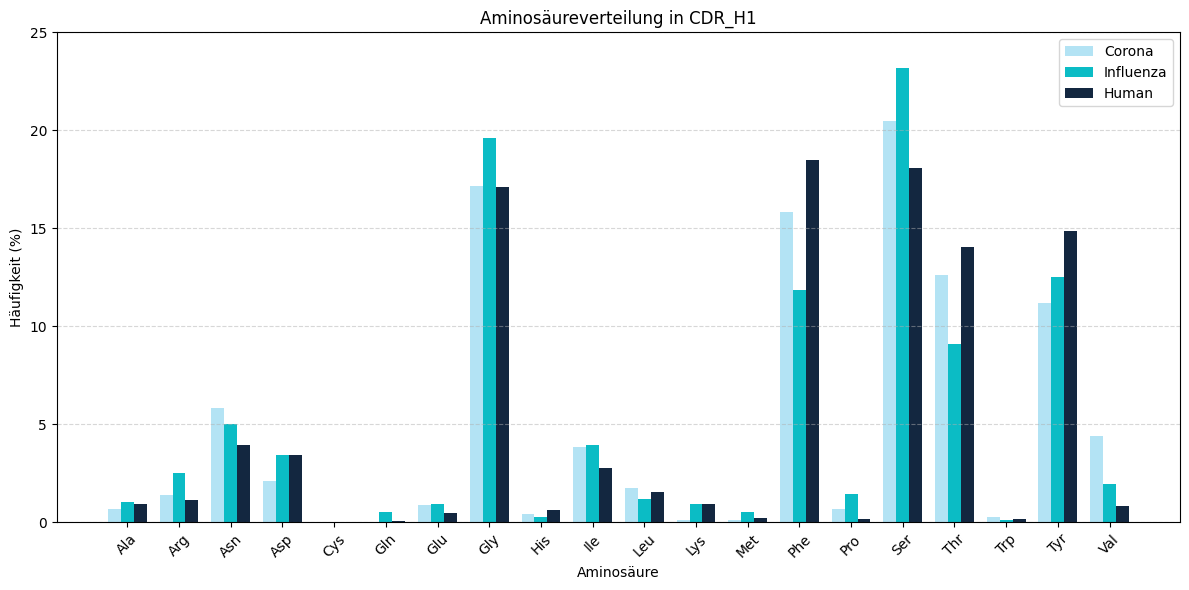

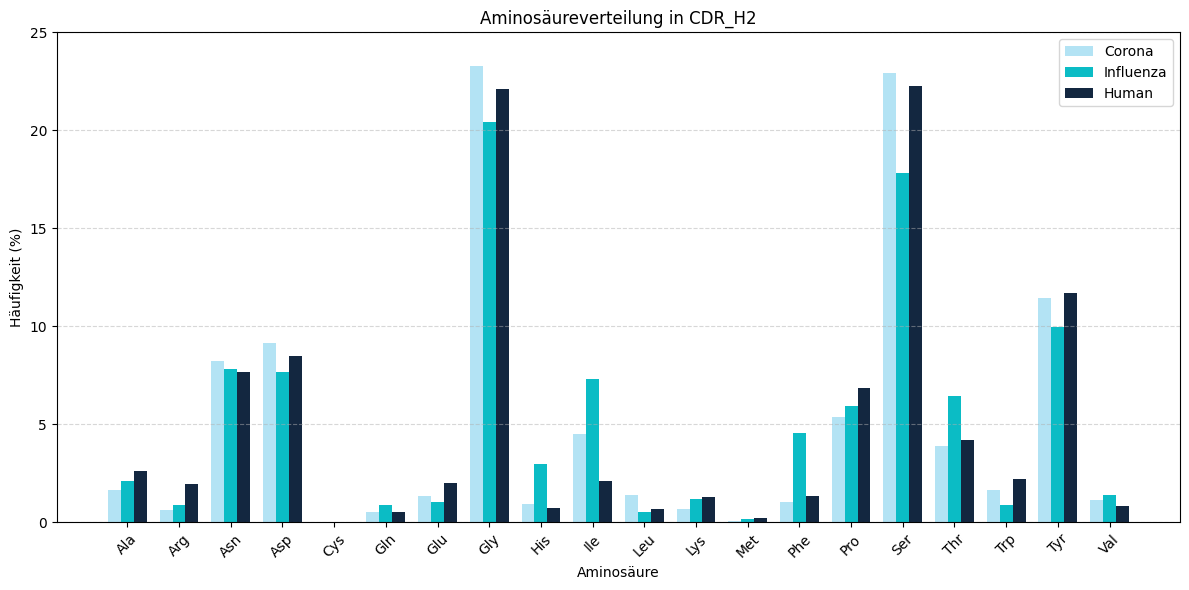

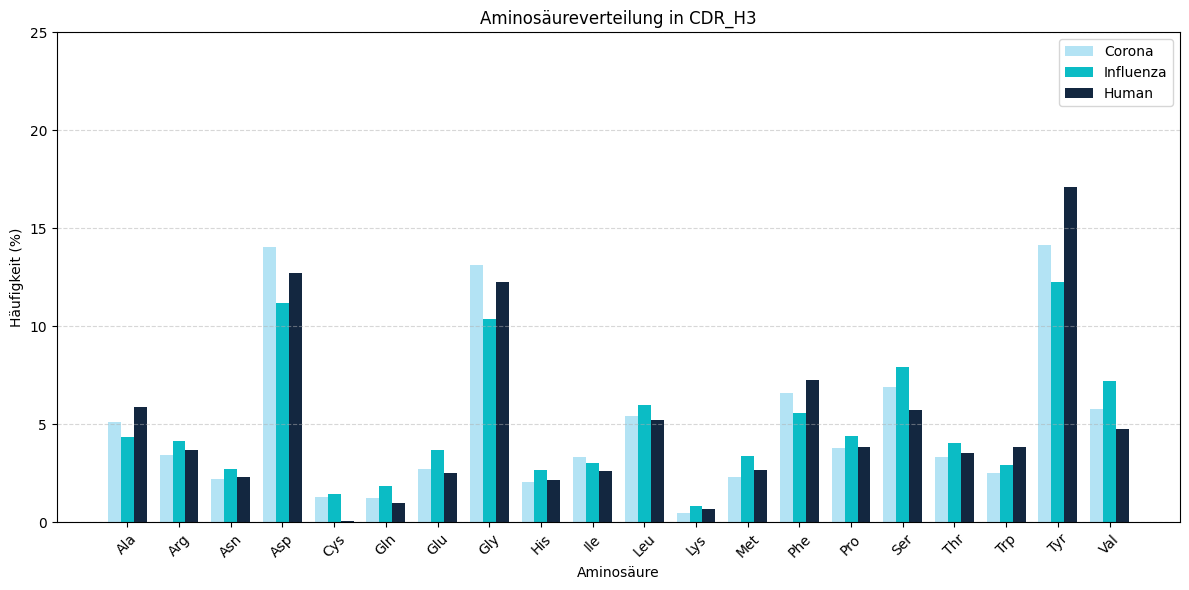

In [52]:
for region in ["CDR_H1", "CDR_H2", "CDR_H3"]: # für jede Region in der Liste "region" wird die Funktion plot_grouped_aa_distribution aufgerufen
    plot_grouped_aa_distribution(
        calculate_aa_distribution(df_corona, region), # Berechnung der Aminosäureverteilung für Corona
        calculate_aa_distribution(df_influenza, region), # Berechnung der Aminosäureverteilung für Influenza
        calculate_aa_distribution(df_human, region), # Berechnung der Aminosäureverteilung für Human
        region_label=region
    )


## Mann-Withney-U-Test

In [9]:
def compute_aa_frequencies(df, colname, group_label): #berechnet die relative Häufigkeit der Aminosäuren in der angegebenen Spalte
    def rel_freq(seq):
        counts = pd.Series(list(seq)).value_counts() #zähle wie oft jede Aminosäure vorkommt
        total = len(seq) #berechne die Gesamtlänge der Sequenz
        return counts / total if total > 0 else pd.Series(dtype=float) #rückgabe der relativen Häufigkeit der Aminosäuren, wenn die Gesamtlänge größer als 0 ist, sonst eine leere Serie

    aa_df = df[colname].dropna().apply(rel_freq).fillna(0) #spalte colname wird auf NaN-Werte überprüft und die relative Häufigkeit der Aminosäuren wird berechnet
    aa_df["group"] = group_label # füge eine neue Spalte "group" hinzu, die den Gruppennamen enthält
    return aa_df

corona_aa = compute_aa_frequencies(df_corona, "CDR_H3", "Corona") 
influenza_aa = compute_aa_frequencies(df_influenza, "CDR_H3", "Influenza")
human_aa = compute_aa_frequencies(df_human, "CDR_H3", "Human")

all_aa = pd.concat([corona_aa, influenza_aa, human_aa], ignore_index=True).fillna(0) # Kombiniere alle Aminosäureverteilungen in einem DataFrame

all_aa

,F,T,D,Y,G,N,E,W,L,P,...,I,H,S,A,V,Q,C,K,M,group
0,0.250000,0.187500,0.187500,0.125000,0.062500,0.062500,0.062500,0.062500,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,Corona
1,0.000000,0.000000,0.111111,0.111111,0.111111,0.000000,0.111111,0.000000,0.222222,0.111111,...,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,Corona
2,0.047619,0.047619,0.142857,0.095238,0.190476,0.095238,0.000000,0.095238,0.047619,0.047619,...,0.000000,0.047619,0.047619,0.047619,0.047619,0.000000,0.0,0.0,0.000000,Corona
3,0.000000,0.000000,0.166667,0.083333,0.250000,0.000000,0.000000,0.083333,0.250000,0.000000,...,0.083333,0.000000,0.000000,0.000000,0.000000,0.083333,0.0,0.0,0.000000,Corona
4,0.000000,0.000000,0.166667,0.083333,0.250000,0.000000,0.000000,0.083333,0.250000,0.000000,...,0.083333,0.000000,0.000000,0.000000,0.000000,0.083333,0.0,0.0,0.000000,Corona
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,0.083333,0.000000,0.083333,0.250000,0.000000,0.000000,0.000000,0.083333,0.000000,0.166667,...,0.000000,0.000000,0.083333,0.166667,0.083333,0.000000,0.0,0.0,0.000000,Human
853,0.076923,0.000000,0.153846,0.153846,0.153846,0.000000,0.000000,0.076923,0.076923,0.076923,...,0.000000,0.000000,0.230769,0.000000,0.000000,0.000000,0.0,0.0,0.000000,Human
854,0.058824,0.000000,0.058824,0.235294,0.117647,0.058824,0.000000,0.000000,0.058824,0.000000,...,0.058824,0.000000,0.058824,0.058824,0.176471,0.000000,0.0,0.0,0.058824,Human
855,0.272727,0.000000,0.090909,0.181818,0.000000,0.000000,0.000000,0.000000,0.090909,0.090909,...,0.000000,0.000000,0.000000,0.090909,0.090909,0.000000,0.0,0.0,0.090909,Human


In [10]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def mann_whitney_comparison(df1, df2, aa_list, label1="Group1", label2="Group2"):
    results = []
    for aa in aa_list:
        group1 = df1[aa] if aa in df1 else pd.Series([0]*len(df1))
        group2 = df2[aa] if aa in df2 else pd.Series([0]*len(df2))
        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
        results.append((aa, aa_1_to_3[aa], group1.mean(), group2.mean(), p))
    df_result = pd.DataFrame(results, columns=["AA", "AA_3", f"Mean_{label1}", f"Mean_{label2}", "p_value"])
    df_result["adjusted_p"] = multipletests(df_result["p_value"], method="fdr_bh")[1]
    return df_result.sort_values("adjusted_p")


In [11]:
all_results = {}

for region in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f" Vergleich für {region}...")

    # Frequenzen berechnen
    corona = compute_aa_frequencies(df_corona, region, "Corona")
    influenza = compute_aa_frequencies(df_influenza, region, "Influenza")
    human = compute_aa_frequencies(df_human, region, "Human")

    aa_list = list(aa_1_to_3.keys())

    # Paarvergleiche
    result_ci = mann_whitney_comparison(corona, influenza, aa_list, "Corona", "Influenza")
    result_ch = mann_whitney_comparison(corona, human, aa_list, "Corona", "Human")
    result_ih = mann_whitney_comparison(influenza, human, aa_list, "Influenza", "Human")

    # Speichern
    all_results[f"{region}_Corona_vs_Influenza"] = result_ci
    all_results[f"{region}_Corona_vs_Human"] = result_ch
    all_results[f"{region}_Influenza_vs_Human"] = result_ih

for name, df in all_results.items():
    print(f"\n🔎 {name}")
    print(df[["AA_3", f"Mean_{name.split('_vs_')[0].split('_')[-1]}", f"Mean_{name.split('_vs_')[-1]}", "adjusted_p"]].head(5))



 Vergleich für CDR_H1...
 Vergleich für CDR_H2...
 Vergleich für CDR_H3...

🔎 CDR_H1_Corona_vs_Influenza
   AA_3  Mean_Corona  Mean_Influenza  adjusted_p
16  Thr     0.127739        0.094484    0.001102
11  Lys     0.000966        0.009603    0.001273
19  Val     0.043986        0.017302    0.001273
5   Gln     0.000378        0.005536    0.005631
13  Phe     0.160703        0.125754    0.013181

🔎 CDR_H1_Corona_vs_Human
   AA_3  Mean_Corona  Mean_Human    adjusted_p
19  Val     0.043986    0.007701  1.245331e-16
18  Tyr     0.113909    0.150270  4.017810e-06
11  Lys     0.000966    0.009800  2.845861e-05
2   Asn     0.058443    0.040101  1.202624e-03
13  Phe     0.160703    0.188733  1.202624e-03

🔎 CDR_H1_Influenza_vs_Human
   AA_3  Mean_Influenza  Mean_Human  adjusted_p
13  Phe        0.125754    0.188733    0.000003
14  Pro        0.015714    0.001717    0.000015
16  Thr        0.094484    0.142627    0.000016
1   Arg        0.026190    0.011282    0.005333
7   Gly        0.194702 

In [12]:
all_dfs = []  # Liste zum Speichern aller DataFrames für die finale Zusammenführung
for name, df in all_results.items(): # Durchlaufe alle Ergebnisse
    region, comparison = name.split("_", 1) # Teile den Namen in Region und Vergleich
    df = df.copy() # Erstelle eine Kopie des DataFrames, um Änderungen vorzunehmen
    df["region"] = region # Füge die Region als neue Spalte hinzu
    df["comparison"] = comparison # Füge den Vergleich als neue Spalte hinzu
    all_dfs.append(df) # Füge den DataFrame der Liste hinzu

# Kombiniere alle DataFrames in der Liste zu einem einzigen DataFrame
df_combined = pd.concat(all_dfs, ignore_index=True) #
df_combined = df_combined[["region", "comparison", "AA_3", "Mean_Corona", "Mean_Influenza", "Mean_Human", "p_value", "adjusted_p"]] #df_combined wird auf die gewünschten Spalten reduziert

df_combined

,region,comparison,AA_3,Mean_Corona,Mean_Influenza,Mean_Human,p_value,adjusted_p
0,CDR,H1_Corona_vs_Influenza,Thr,0.127739,0.094484,NaN,0.000055,0.001102
1,CDR,H1_Corona_vs_Influenza,Lys,0.000966,0.009603,NaN,0.000156,0.001273
2,CDR,H1_Corona_vs_Influenza,Val,0.043986,0.017302,NaN,0.000191,0.001273
3,CDR,H1_Corona_vs_Influenza,Gln,0.000378,0.005536,NaN,0.001126,0.005631
4,CDR,H1_Corona_vs_Influenza,Phe,0.160703,0.125754,NaN,0.003295,0.013181
...,...,...,...,...,...,...,...,...
175,CDR,H3_Influenza_vs_Human,Gly,NaN,0.106963,0.125386,0.091958,0.114947
176,CDR,H3_Influenza_vs_Human,Lys,NaN,0.007657,0.005306,0.116916,0.137548
177,CDR,H3_Influenza_vs_Human,Pro,NaN,0.042723,0.037324,0.208379,0.231532
178,CDR,H3_Influenza_vs_Human,Trp,NaN,0.028678,0.038795,0.343751,0.361843


In [13]:
# Leeres Dictionary für Heatmap-Daten
heatmap_data = {}

# Schleife über alle gespeicherten Ergebnisse
for name, df in all_results.items():
    row_label = name.replace("_", ": ").replace("CDR", "CDR-")  # schöner formatieren
    row = {aa_1_to_3[aa]: -np.log10(p) if p > 0 else 10 for aa, p in zip(df["AA"], df["adjusted_p"])}
    heatmap_data[row_label] = row

import pandas as pd
import numpy as np

df_heatmap = pd.DataFrame.from_dict(heatmap_data, orient="index").fillna(0)



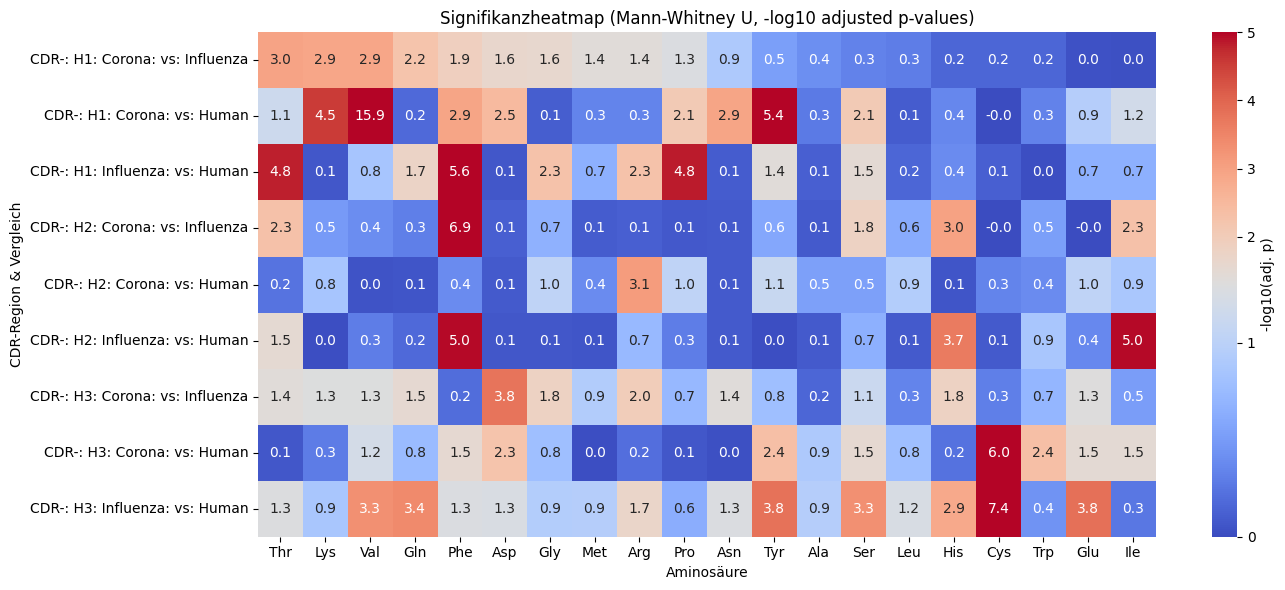

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Normierung der Farbskala: Mitte = 1.3
norm = TwoSlopeNorm(vmin=0, vcenter=1.3, vmax=5)

plt.figure(figsize=(14, 6))
sns.heatmap(
    df_heatmap,
    cmap="coolwarm",          # blau–weiß–rot-Verlauf
    annot=True,
    fmt=".1f",
    cbar_kws={'label': '-log10(adj. p)'},
    norm=norm                 # kritischer Punkt bei 1.3
)

plt.title("Signifikanzheatmap (Mann-Whitney U, -log10 adjusted p-values)")
plt.xlabel("Aminosäure")
plt.ylabel("CDR-Region & Vergleich")
plt.tight_layout()
plt.show()


C:\Users\082mi\AppData\Local\Temp\ipykernel_18472\2022203506.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])


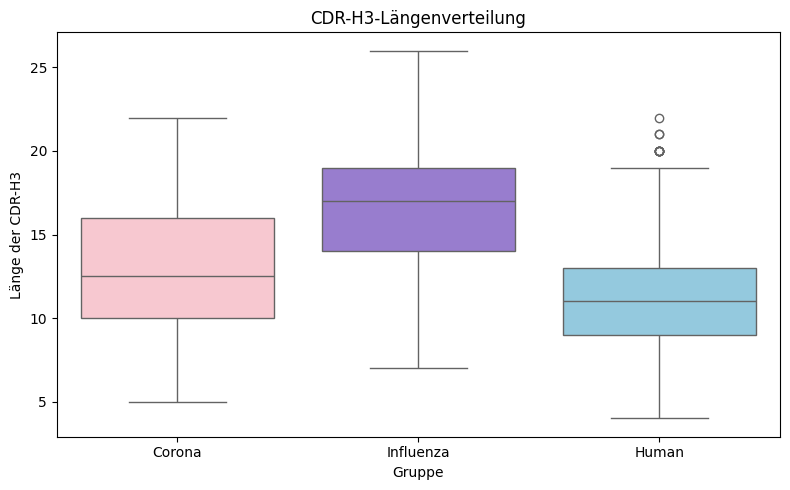

In [15]:
import pandas as pd
# Load the datasets


df_corona["length"] = df_corona["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_corona["group"] = "Corona"

df_influenza["length"] = df_influenza["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_influenza["group"] = "Influenza"

df_human["length"] = df_human["CDR_H3"].apply(lambda x: len(x) if isinstance(x, str) else 0)
df_human["group"] = "Human"

df_lengths = pd.concat([df_corona, df_influenza, df_human], ignore_index=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_lengths, x="group", y="length", palette=["pink", "mediumpurple", "skyblue"])
plt.title("CDR-H3-Längenverteilung")
plt.ylabel("Länge der CDR-H3")
plt.xlabel("Gruppe")
plt.tight_layout()
plt.show()



## Amino Acid Composition by groups

In [16]:
# zuordnen der Aminosäuren zu ihren Eigenschaften
aa_properties = {
    'A': 'unpolar',  # Ala
    'V': 'unpolar',  # Val
    'L': 'unpolar',  # Leu
    'I': 'unpolar',  # Ile
    'M': 'unpolar',  # Met
    'F': 'aromatisch',  # Phe
    'W': 'aromatisch',  # Trp
    'P': 'unpolar',  # Pro
    'G': 'unpolar',  # Gly
    'C': 'polar',    # Cys (schwach polar)

    'S': 'polar',    # Ser
    'T': 'polar',    # Thr
    'N': 'polar',    # Asn
    'Q': 'polar',    # Gln
    'Y': 'aromatisch',  # Tyr (polar, aber aromatisch)

    'K': 'basisch',  # Lys
    'R': 'basisch',  # Arg
    'H': 'basisch',  # His

    'D': 'sauer',    # Asp
    'E': 'sauer'     # Glu
}

# Funktion zum Gruppieren der Aminosäuren nach ihren Eigenschaften
def group_by_property(row):
    grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
    for aa, freq in row.items(): #Iteration über die Aminosäuren und deren Häufigkeit
        if aa in aa_properties: #   prüfen ob die Aminosäure in aa_properties enthalten ist
            prop = aa_properties[aa] #  bestimme die Eigenschaft der Aminosäure
            grouped[prop] += freq # addiere die Häufigkeit der Aminosäure zu der entsprechenden Eigenschaft
    return pd.Series(grouped) 


# Group by properties for CDR-H3
aac_sars_props_h3 = aac_sars_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h3["group"] = "Corona"
aac_influenza_props_h3 = aac_influenza_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h3["group"] = "Influenza"
aac_human_props_h3 = aac_human_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h3["group"] = "Human"

# Group by properties for CDR-H2
aac_sars_props_h2 = aac_sars_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h2["group"] = "Corona"    
aac_influenza_props_h2 = aac_influenza_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h2["group"] = "Influenza"
aac_human_props_h2 = aac_human_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h2["group"] = "Human"

# Group by properties for CDR-H1
aac_sars_props_h1 = aac_sars_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h1["group"] = "Corona"       
aac_influenza_props_h1 = aac_influenza_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h1["group"] = "Influenza"   
aac_human_props_h1 = aac_human_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h1["group"] = "Human"



NameError: name 'aac_sars_h3' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_property_groups(aac_sars, aac_influenza, aac_human, region_label="CDR-H3"):
    # Gruppierung nach chemischen Eigenschaften
    def group_by_property(row):
        aa_properties = {
            'A': 'unpolar', 'V': 'unpolar', 'L': 'unpolar', 'I': 'unpolar', 'M': 'unpolar',
            'F': 'aromatisch', 'W': 'aromatisch', 'P': 'unpolar', 'G': 'unpolar', 'C': 'polar',
            'S': 'polar', 'T': 'polar', 'N': 'polar', 'Q': 'polar', 'Y': 'aromatisch',
            'K': 'basisch', 'R': 'basisch', 'H': 'basisch',
            'D': 'sauer', 'E': 'sauer'
        }
        grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
        for aa, freq in row.items():
            if aa in aa_properties:
                grouped[aa_properties[aa]] += freq
        return pd.Series(grouped)

    # Anwendung auf alle Gruppen
    props_sars = aac_sars.drop(columns="group").apply(group_by_property, axis=1)
    props_influenza = aac_influenza.drop(columns="group").apply(group_by_property, axis=1)
    props_human = aac_human.drop(columns="group").apply(group_by_property, axis=1)

    # Mittelwerte berechnen
    mean_sars = props_sars.mean()
    mean_influenza = props_influenza.mean()
    mean_human = props_human.mean()

    # Plot-DataFrame
    df_props_plot = pd.DataFrame({
        "Eigenschaft": mean_sars.index,
        "Corona": mean_sars.values,
        "Influenza": mean_influenza.values,
        "Human": mean_human.values
    })

    # Balkendiagramm
    x = np.arange(len(df_props_plot["Eigenschaft"]))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, df_props_plot["Corona"], width=width, label="Corona", color="pink")
    plt.bar(x,         df_props_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
    plt.bar(x + width, df_props_plot["Human"], width=width, label="Human", color="skyblue")

    plt.xticks(ticks=x, labels=df_props_plot["Eigenschaft"])
    plt.ylabel("Relative Häufigkeit der Aminosäuregruppen")
    plt.xlabel("Aminosäuregruppe")
    plt.title(f"Eigenschaften der Aminosäuren in {region_label}")
    plt.ylim(0, 0.40)  # Fixiere Y-Achse auf Bereich 0 bis 0.40
    plt.legend()
    plt.tight_layout()
    plt.show()


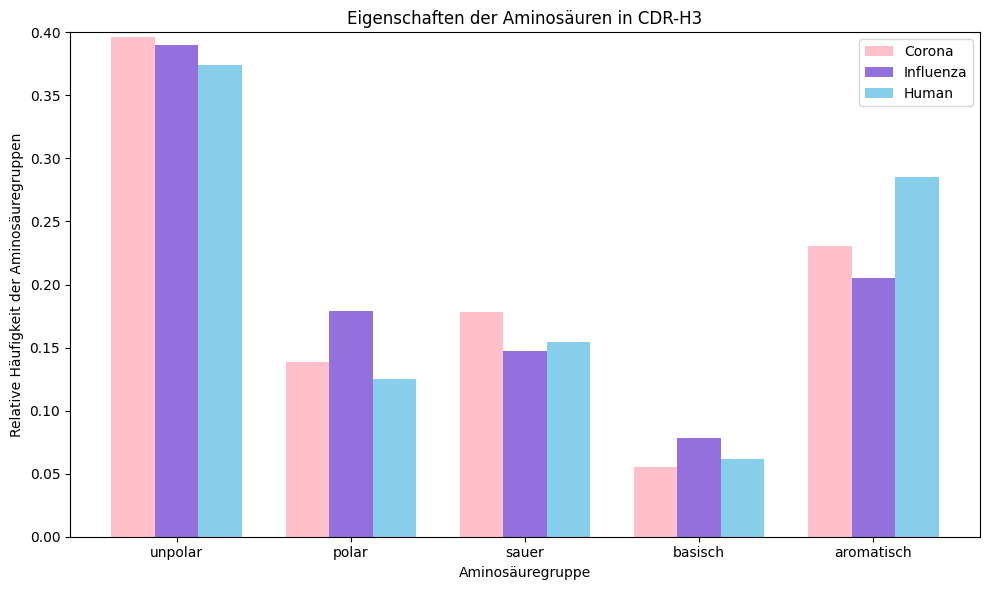

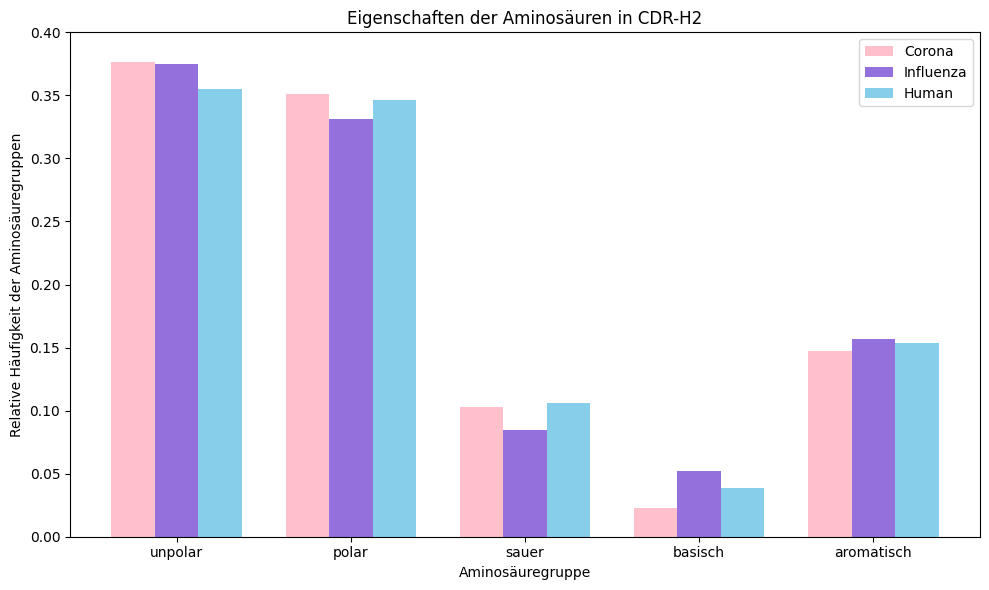

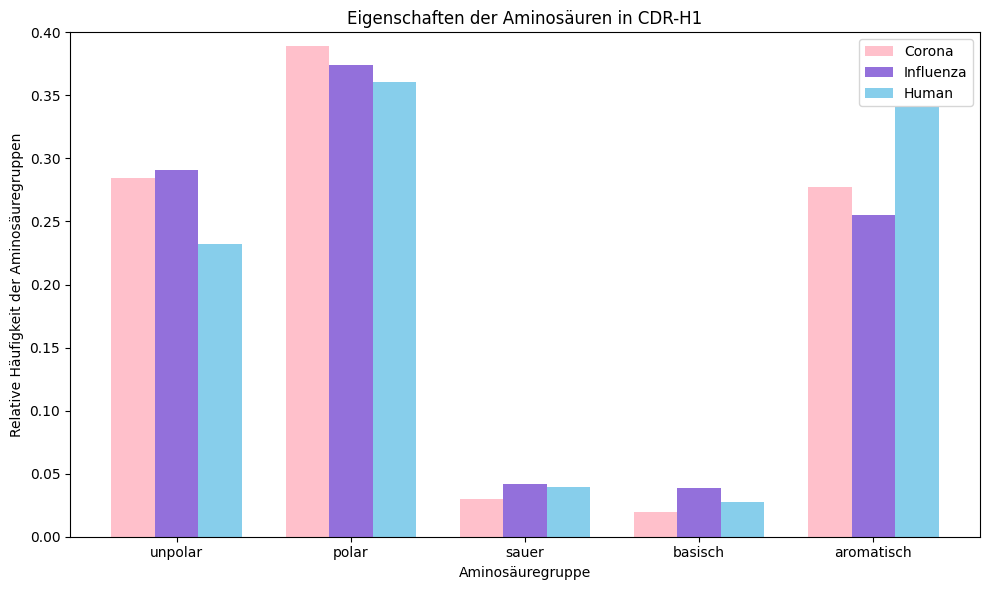

In [ ]:
plot_property_groups(aac_sars_h3, aac_influenza_h3, aac_human_h3, region_label="CDR-H3")
plot_property_groups(aac_sars_h2, aac_influenza_h2, aac_human_h2, region_label="CDR-H2")
plot_property_groups(aac_sars_h1, aac_influenza_h1, aac_human_h1, region_label="CDR-H1")
